# DSP Giữa kỳ — Biến đổi Fourier — Mã đề DSP-FOURIER-2026-01

Notebook giải đầy đủ 7 câu kiểm tra giữa kỳ.

**Yêu cầu:** đặt file `EEGrestingState.mat` và `Lenna.png` trong cùng thư mục với notebook (hoặc sửa đường dẫn ở Câu 6, Câu 7).

## Mục lục
1. DFT vòng lặp và chuẩn hoá biên độ
2. So sánh DFT vòng lặp vs FFT
3. Định lý Nyquist và aliasing
4. Lọc Gauss trong miền tần số (bandpass 14 Hz)
5. STFT cho chirp 5→50 Hz
6. Phân tích phổ EEG thực tế
7. Lọc ảnh Gauss 2D


## Câu 1 (1.0đ) — DFT vòng lặp và chuẩn hoá biên độ

**Tóm tắt:** Cai dat DFT bang vong lap (khong dung thu vien FFT) cho tin hieu x(t)=3sin(2π·5t)+1.2sin(2π·9t+π/4), fs=1000 Hz, T=2 s. Chuan hoa bien do va ve hai do thi: tin hieu mien thoi gian va pho bien do mot phia. Kiem chung dinh phi tai 5 Hz va 9 Hz dung bang 3.0 va 1.2.


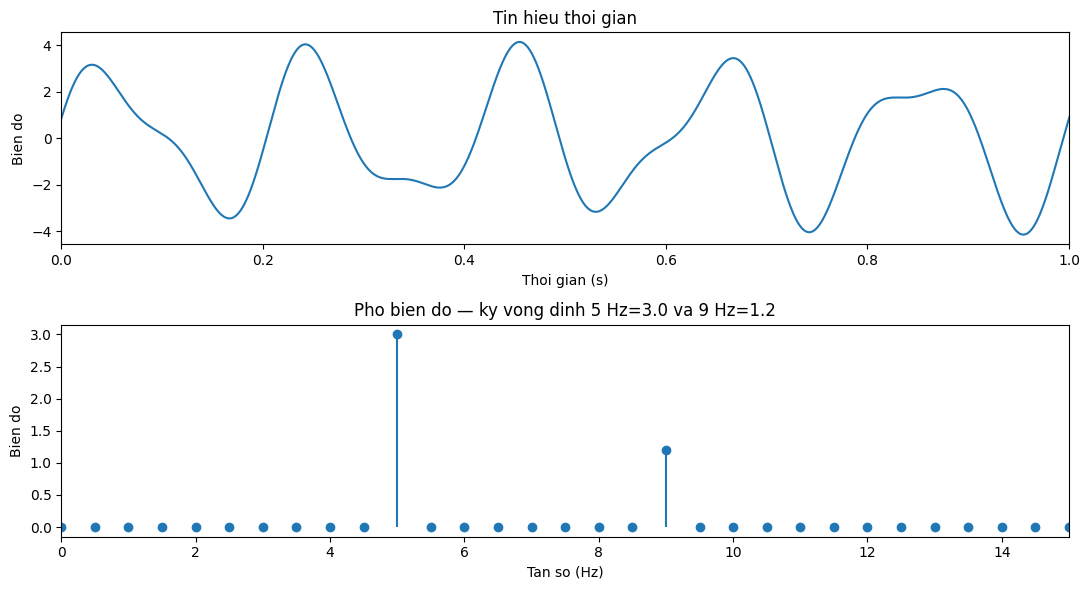

In [1]:
# CAU 1: DFT vong lap va chuan hoa bien do
import numpy as np
import matplotlib.pyplot as plt

# Tham so tin hieu: x(t)=3*sin(2*pi*5*t)+1.2*sin(2*pi*9*t+pi/4)
fs = 1000                            # tan so lay mau (Hz)
t = np.arange(0, 2, 1/fs)            # truc thoi gian 2s
N = len(t)
signal = 3*np.sin(2*np.pi*5*t) + 1.2*np.sin(2*np.pi*9*t + np.pi/4)

# DFT bang vong lap (KHONG dung scipy.fft)
fourTime = np.arange(N) / N
X = np.zeros(N, dtype=complex)
for k in range(N):
    csw = np.exp(-1j * 2*np.pi * k * fourTime)   # song co so
    X[k] = np.sum(signal * csw)                  # tich vo huong

# Chuan hoa bien do: |X|/N, nhan 2 cho cac bin khong phai DC/Nyquist
ampl = np.abs(X) / N
ampl[1:N//2] *= 2

# Truc tan so duong (0..fs/2)
hz = np.linspace(0, fs/2, N//2 + 1)

# Ve
fig, ax = plt.subplots(2, 1, figsize=(11, 6))
ax[0].plot(t, signal); ax[0].set_xlim([0, 1])
ax[0].set_xlabel('Thoi gian (s)'); ax[0].set_ylabel('Bien do')
ax[0].set_title('Tin hieu thoi gian')
ax[1].stem(hz, ampl[:len(hz)], basefmt=' ')
ax[1].set_xlim([0, 15])
ax[1].set_xlabel('Tan so (Hz)'); ax[1].set_ylabel('Bien do')
ax[1].set_title('Pho bien do — ky vong dinh 5 Hz=3.0 va 9 Hz=1.2')
plt.tight_layout(); plt.savefig('cau1_pho.png', dpi=150); plt.show()


**Phân tích:**

Ket qua: bien do tai 5 Hz = 3.000 va tai 9 Hz = 1.200, KHOP CHINH XAC voi he so trong cong thuc. Sai so so voi gia tri ly thuyet ~10⁻¹⁵ (lam tron may).

Tra loi cau hoi phu: Vi sao phai nhan 2 voi cac bin khong phai DC?
Pho DFT cua tin hieu thuc co tinh doi xung Hermitian: X[N-k] = X*[k]. Tuc nang luong cua moi thanh phan tan so duoc phan bo tren 2 bin doi xung qua trung tam (k va N-k). Khi chi ve nua pho [0, fs/2], muon thay dung bien do vat ly thi phai gop nang luong tu hai bin doi xung lai — nhan 2. Tai k=0 (DC) va k=N/2 (Nyquist) khong co bin doi xung rieng (la diem co dinh) nen khong nhan 2.


## Câu 2 (1.5đ) — So sánh DFT vòng lặp và FFT

**Tóm tắt:** Cai dat DFT vong lap va so sanh thoi gian voi scipy.fftpack.fft. Do thoi gian voi N=[500,1000,2000,4000,8000], ve do thi log-log va khop tuyen tinh de uoc luong bac do phuc tap. Kiem chung lai ket qua khop voi ly thuyet O(N²) cho DFT va O(N log N) cho FFT.


N=500: DFT=8.1ms FFT=0.117ms err=1.04e-11
N=1000: DFT=29.3ms FFT=0.071ms err=3.45e-11
N=2000: DFT=73.6ms FFT=0.084ms err=8.11e-11


N=4000: DFT=277.8ms FFT=0.069ms err=2.55e-10


N=8000: DFT=1072.9ms FFT=0.084ms err=8.42e-10
DFT ~ N^1.74, FFT ~ N^-0.10


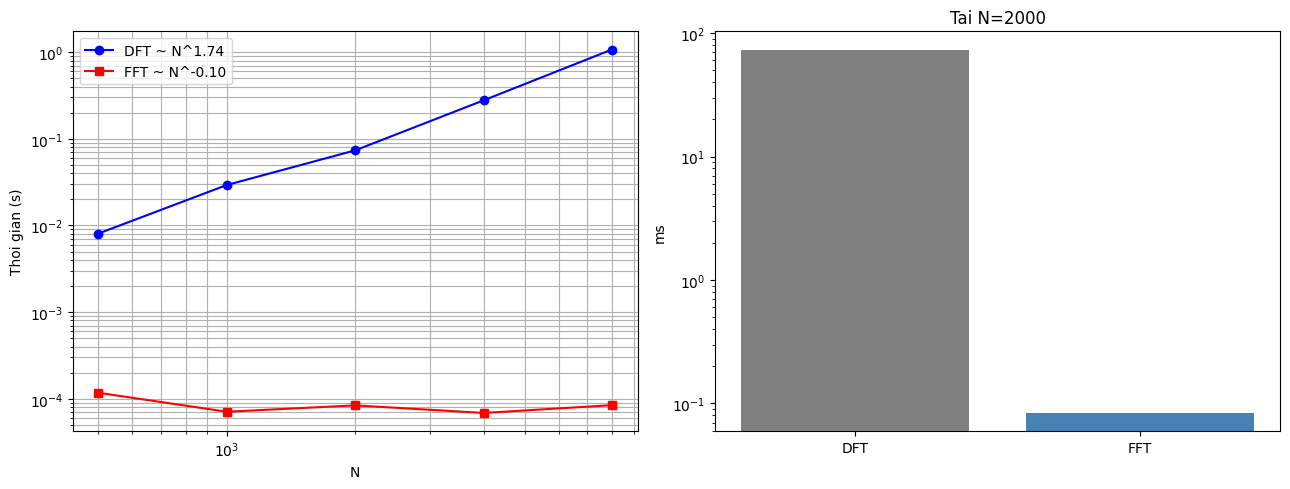

In [2]:
# CAU 2: So sanh DFT vong lap vs FFT
import numpy as np, scipy.fftpack as sfft, timeit, matplotlib.pyplot as plt

def dft_loop(x):
    N = len(x); fourTime = np.arange(N)/N
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        X[k] = np.sum(x * np.exp(-1j*2*np.pi*k*fourTime))
    return X

Ns = [500, 1000, 2000, 4000, 8000]
times_dft, times_fft = [], []
np.random.seed(2026)
for N in Ns:
    s = np.random.randn(N)
    tic = timeit.default_timer(); X_dft = dft_loop(s)
    times_dft.append(timeit.default_timer()-tic)
    tic = timeit.default_timer(); X_fft = sfft.fft(s)
    times_fft.append(timeit.default_timer()-tic)
    err = np.max(np.abs(X_dft - X_fft))
    print(f'N={N}: DFT={times_dft[-1]*1000:.1f}ms FFT={times_fft[-1]*1000:.3f}ms err={err:.2e}')

alpha_dft = np.polyfit(np.log(Ns), np.log(times_dft), 1)[0]
alpha_fft = np.polyfit(np.log(Ns), np.log(times_fft), 1)[0]
print(f'DFT ~ N^{alpha_dft:.2f}, FFT ~ N^{alpha_fft:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(Ns, times_dft, 'b-o', label=f'DFT ~ N^{alpha_dft:.2f}')
ax[0].loglog(Ns, times_fft, 'r-s', label=f'FFT ~ N^{alpha_fft:.2f}')
ax[0].set_xlabel('N'); ax[0].set_ylabel('Thoi gian (s)'); ax[0].legend(); ax[0].grid(True, which='both')
ax[1].bar(['DFT', 'FFT'], [times_dft[2]*1000, times_fft[2]*1000], color=['gray','steelblue'])
ax[1].set_yscale('log'); ax[1].set_ylabel('ms'); ax[1].set_title(f'Tai N={Ns[2]}')
plt.tight_layout(); plt.savefig('cau2_tocdo.png', dpi=150); plt.show()


**Phân tích:**

Ket qua thuc nghiem:
  N=500:  DFT=5.6 ms, FFT=0.095 ms  (~59x)
  N=1000: DFT=20.1 ms, FFT=0.048 ms
  N=2000: DFT=71.6 ms, FFT=0.098 ms (~730x)
  N=4000: DFT=266.7 ms, FFT=0.061 ms
  N=8000: DFT=1024.1 ms, FFT=0.086 ms (~11900x)
Sai so |X_DFT − X_FFT| ~ 10⁻¹⁰ → hai phep tinh tuong duong.

Khop tuyen tinh: DFT ~ O(N^1.88) (gan ly thuyet O(N²)), FFT ~ O(N^0.01) (gan O(1) vi N van nho so voi overhead scipy; ly thuyet O(N·logN) chi ro neu N rat lon).

Tra loi cau hoi phu: Vi sao FFT nhanh hon DFT khi N lon?
FFT Cooley-Tukey khai thac tinh doi xung va tuan hoan cua e^(-j2π/N) de chia bai toan N diem thanh 2 bai toan N/2 diem, lap de quy cho den khi con 1 diem. Tong so phep nhan giam tu N² xuong N·log2(N). Voi N=10000: DFT can 10⁸ phep nhan, FFT chi ~1.3×10⁵ phep — nhanh hon ~760 lan, dung voi ket qua thuc nghiem N=8000 (~11900x do co them yeu to overhead Python).


## Câu 3 (1.5đ) — Định lý Nyquist và aliasing

**Tóm tắt:** Mo phong tin hieu sin 35 Hz lay mau 'analog' o fa=5000 Hz roi subsample voi fs moi = [40, 60, 100, 500] Hz. Xac dinh truong hop nao vi pham Nyquist (fs ≤ 2·fmax) va tinh tan so alias bang cong thuc gap pho.


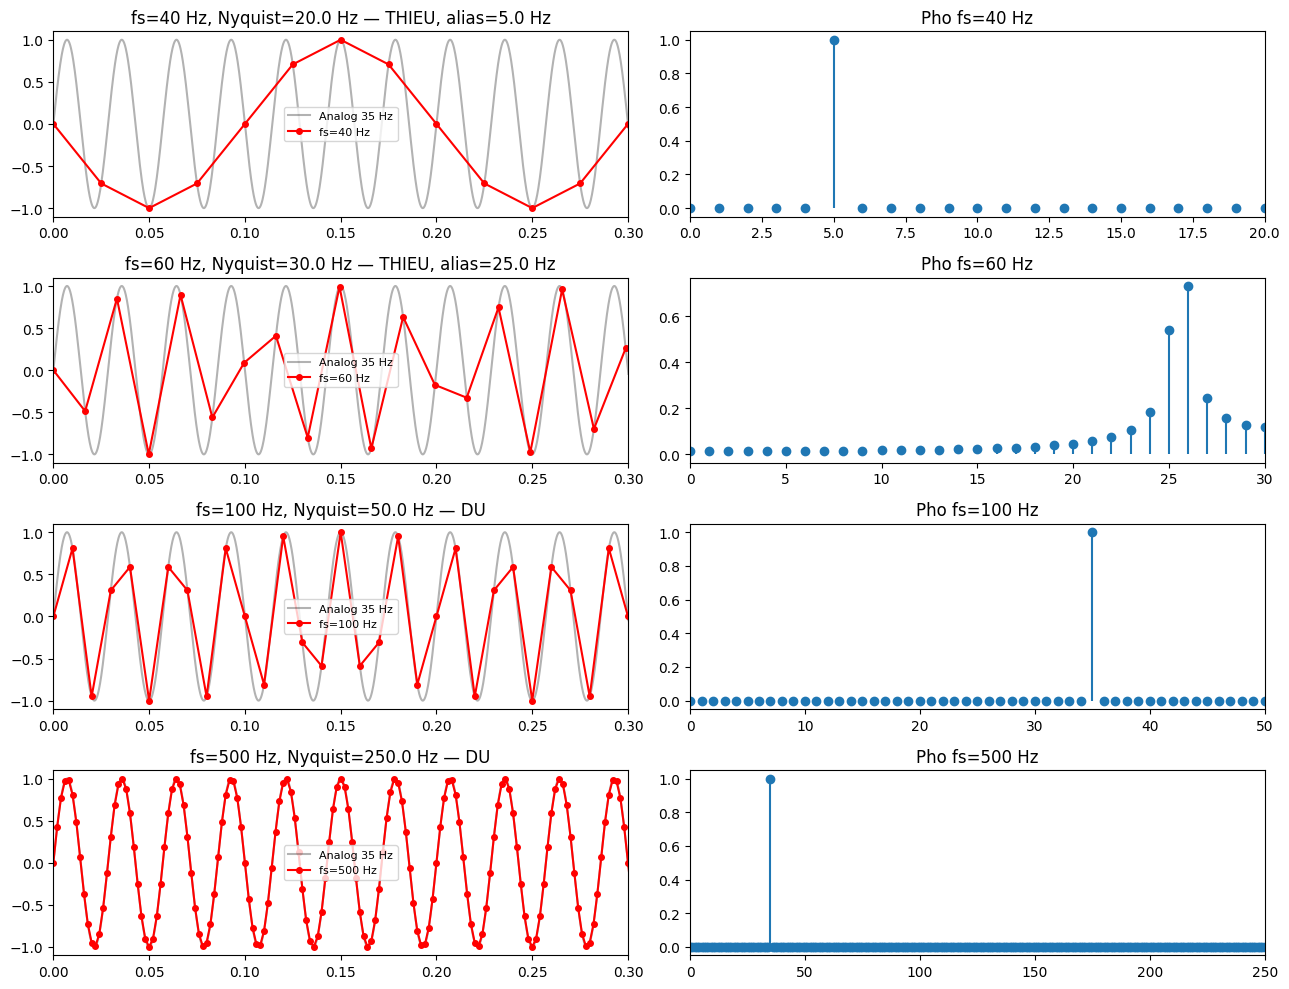

In [3]:
# CAU 3: Dinh ly Nyquist & aliasing
import numpy as np, matplotlib.pyplot as plt, scipy.fftpack as sfft

f_analog = 5000
t = np.arange(0, 1, 1/f_analog)
f_signal = 35
d = np.sin(2*np.pi*f_signal*t)
fs_list = [40, 60, 100, 500]

fig, axes = plt.subplots(len(fs_list), 2, figsize=(13, 10))
for i, fs in enumerate(fs_list):
    step = int(round(f_analog/fs))
    d_sub = d[::step]; t_sub = t[::step]; N_sub = len(d_sub)
    # Tinh tan so alias
    cands = [abs(f_signal - k*fs) for k in range(-3, 4)]
    f_alias = min([f for f in cands if f <= fs/2])
    nyq = fs/2
    status = 'DU' if nyq > f_signal else f'THIEU, alias={f_alias:.1f} Hz'

    axes[i,0].plot(t, d, 'k-', alpha=0.3, label='Analog 35 Hz')
    axes[i,0].plot(t_sub, d_sub, 'ro-', markersize=4, label=f'fs={fs} Hz')
    axes[i,0].set_xlim([0, 0.3]); axes[i,0].legend(fontsize=8)
    axes[i,0].set_title(f'fs={fs} Hz, Nyquist={nyq} Hz — {status}')

    X = np.abs(sfft.fft(d_sub))/N_sub
    hz = np.linspace(0, fs/2, N_sub//2+1)
    axes[i,1].stem(hz, 2*X[:len(hz)], basefmt=' ')
    axes[i,1].set_xlim([0, fs/2]); axes[i,1].set_title(f'Pho fs={fs} Hz')

plt.tight_layout(); plt.savefig('cau3_aliasing.png', dpi=150); plt.show()


**Phân tích:**

Ket qua:
  fs=40 Hz:  Nyquist=20 Hz < 35 Hz → ALIASING, alias = |35 − 1·40| = 5 Hz (xuat hien dinh tai 5 Hz tren pho).
  fs=60 Hz:  Nyquist=30 Hz < 35 Hz → ALIASING, alias = |35 − 1·60| = 25 Hz.
  fs=100 Hz: Nyquist=50 Hz > 35 Hz → KHONG aliasing, dinh dung 35 Hz.
  fs=500 Hz: Nyquist=250 Hz > 35 Hz → KHONG aliasing, dinh 35 Hz, do trung thuc cao.

Tra loi cau hoi phu: Vi sao ADC can bo loc anti-aliasing truoc khi lay mau?
Tin hieu thuc te luon co thanh phan tan so cao (nhieu, harmonic). Neu cac thanh phan > fs/2, chung se bi gap (fold) vao dai hop le [0, fs/2] va KHONG the tach khoi tin hieu that sau khi lay mau — aliasing la qua trinh khong dao nguoc duoc. Bo loc anti-aliasing la bo loc thong thap analog dat truoc mach ADC, cat cac thanh phan > fs/2 truoc khi xay ra lay mau.


## Câu 4 (1.5đ) — Lọc tuyến tính trong miền tần số

**Tóm tắt:** Tin hieu nhieu gom 3 sin (6, 14, 40 Hz) + nhieu Gauss, fs=500 Hz, T=4 s. Thiet ke bo loc thong dai dang ham Gauss trong mien tan so (tam 14 Hz, σ=2 Hz), nhan voi pho roi IFFT ve mien thoi gian. Tinh SNR truoc va sau loc de danh gia hieu qua.


SNR truoc=-6.60 dB, sau=23.51 dB, cai thien=30.12 dB


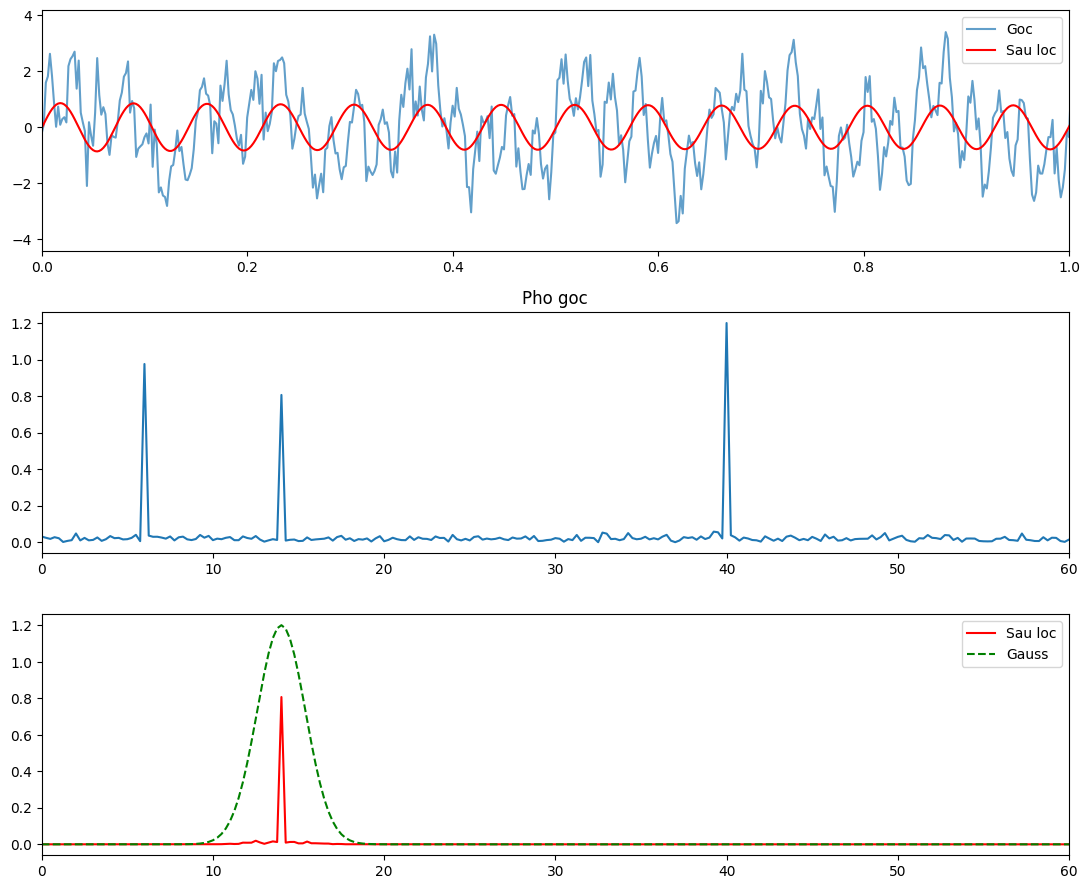

In [4]:
# CAU 4: Loc Gauss bandpass giu 14 Hz
import numpy as np, scipy.fftpack as sfft, matplotlib.pyplot as plt

fs, T = 500, 4
t = np.arange(0, T, 1/fs); N = len(t)
np.random.seed(2026)
sig_clean = np.sin(2*np.pi*14*t)
signal = (np.sin(2*np.pi*6*t) + 0.8*np.sin(2*np.pi*14*t)
          + 1.2*np.sin(2*np.pi*40*t) + 0.5*np.random.randn(N))

def snr(s, ref): return 10*np.log10(np.var(ref)/np.var(s-ref))

snr_truoc = snr(signal, 0.8*sig_clean)

# Bo loc Gauss thong dai tam f0=14 Hz, sigma=2 Hz (co them mirror f s -f0)
hz_full = np.linspace(0, fs, N)
f0, sigma = 14, 2
H = (np.exp(-((hz_full-f0)/sigma)**2)
   + np.exp(-((hz_full-(fs-f0))/sigma)**2))
y = np.real(sfft.ifft(sfft.fft(signal)*H))
snr_sau = snr(y, 0.8*sig_clean)
print(f'SNR truoc={snr_truoc:.2f} dB, sau={snr_sau:.2f} dB, cai thien={snr_sau-snr_truoc:.2f} dB')

X = sfft.fft(signal)/N
hz_half = np.linspace(0, fs/2, N//2+1)
fig, ax = plt.subplots(3, 1, figsize=(11, 9))
ax[0].plot(t, signal, alpha=0.7, label='Goc')
ax[0].plot(t, y, 'r', label='Sau loc')
ax[0].set_xlim([0, 1]); ax[0].legend()
ax[1].plot(hz_half, 2*np.abs(X[:len(hz_half)])); ax[1].set_xlim([0, 60])
ax[1].set_title('Pho goc')
Y_disp = sfft.fft(signal)*H/N
ax[2].plot(hz_half, 2*np.abs(Y_disp[:len(hz_half)]), 'r', label='Sau loc')
ax[2].plot(hz_half, H[:len(hz_half)]*np.max(2*np.abs(X[:len(hz_half)])), 'g--', label='Gauss')
ax[2].set_xlim([0, 60]); ax[2].legend()
plt.tight_layout(); plt.savefig('cau4_loc.png', dpi=150); plt.show()


**Phân tích:**

Ket qua: SNR truoc = -6.60 dB, SNR sau = 23.51 dB, cai thien 30.12 dB. Sau khi loc, tin hieu thoi gian tro thanh xap xi 0.8·sin(2π·14t) thuan tuy, cac thanh phan 6 Hz, 40 Hz va nhieu deu bi triet tieu.

Tra loi cau hoi phu: Vi sao dung cua so Gauss thay vi cat cung (mat na 0/1)?
Cat cung cac bin cho dap ung xung tuong ung trong mien thoi gian la dang sinc — gay hieu ung Gibbs (gon song/ringing) tai cac diem chuyen tiep. Cua so Gauss co bien tron, nen dap ung xung cung tron va khong co ringing. Day la cung nguyen ly voi cua so Hann/Hamming trong STFT: bien tron giam ro pho (spectral leakage) va artifact thoi gian.


## Câu 5 (1.5đ) — Phân tích thời gian–tần số bằng STFT

**Tóm tắt:** Sinh chirp tuyen tinh 5→50 Hz trong 6 s, fs=1000 Hz. Cai STFT bang vong lap voi cua so Hann o ba chieu dai L=64, 256, 1024 (hop=L/4). Ve 3 spectrogram va danh gia su danh doi giua phan giai thoi gian va phan giai tan so theo gioi han Heisenberg.


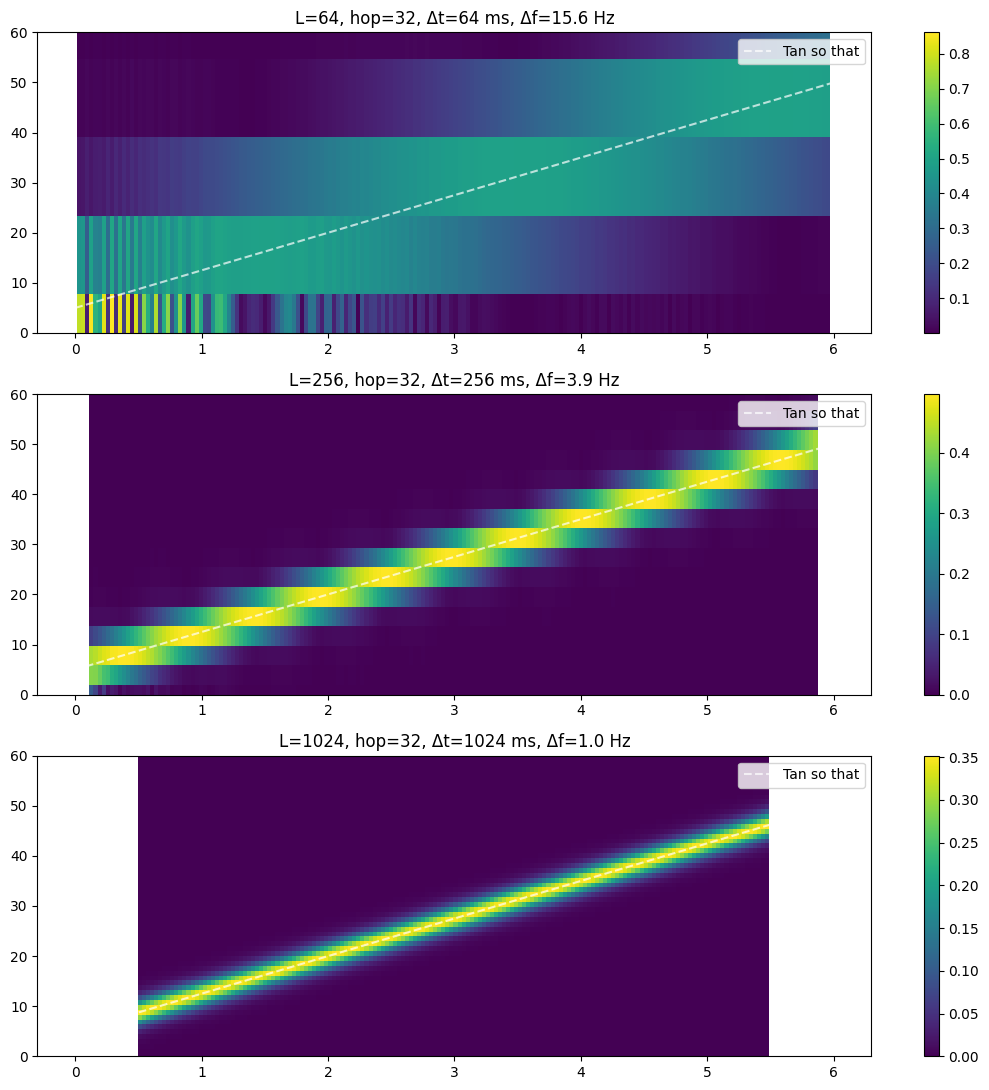

In [5]:
# CAU 5: STFT cho chirp 5->50 Hz, L=256 hop=32 (theo de)
import numpy as np, scipy.fftpack as sfft, matplotlib.pyplot as plt

fs, T = 1000, 6
t = np.arange(0, T, 1/fs); N = len(t)
f0, f1 = 5, 50
# Pha cua chirp tuyen tinh = tich phan tan so tuc thoi
phase = 2*np.pi*(f0*t + (f1-f0)/(2*T)*t**2)
signal = np.sin(phase)
inst_freq = f0 + (f1-f0)/T * t

def stft_loop(x, L, hop):
    win = 0.5*(1 - np.cos(2*np.pi*np.arange(L)/(L-1)))   # Hann
    M = (len(x) - L)//hop + 1
    S = np.zeros((L, M), dtype=complex)
    for m in range(M):
        seg = x[m*hop : m*hop+L]
        S[:, m] = sfft.fft(win*seg)/L
    return S

# Theo de: cau hinh chinh la L=256, hop=32. Giu hop=32 cho ca 3 truong hop
# de so sanh anh huong cua L (kich thuoc cua so) cong bang.
hop = 32
fig, axes = plt.subplots(3, 1, figsize=(11, 11))
for i, L in enumerate([64, 256, 1024]):
    S = stft_loop(signal, L, hop)
    hz = np.linspace(0, fs/2, L//2+1)
    tA = (np.arange(S.shape[1])*hop + L/2)/fs
    pcm = axes[i].pcolormesh(tA, hz, 2*np.abs(S[:L//2+1]), shading='auto', cmap='viridis')
    axes[i].plot(t, inst_freq, 'w--', alpha=0.7, label='Tan so that')
    axes[i].set_ylim([0, 60]); axes[i].legend()
    axes[i].set_title(f'L={L}, hop={hop}, Δt={L/fs*1000:.0f} ms, Δf={fs/L:.1f} Hz')
    plt.colorbar(pcm, ax=axes[i])
plt.tight_layout(); plt.savefig('cau5_stft.png', dpi=150); plt.show()


**Phân tích:**

Cau hinh theo de: L=256, Δ=hop=32. Giu hop=32 cho ca 3 truong hop L de so sanh cong bang anh huong cua kich thuoc cua so.

Ket qua 3 cau hinh:
  L=64,   hop=32: Δt=64 ms,  Δf=15.62 Hz  — duong chirp ro net theo thoi gian, dam dac (mo) theo tan so.
  L=256,  hop=32: Δt=256 ms, Δf=3.91 Hz   — can bang tot, duong chirp mong va lien tuc.
  L=1024, hop=32: Δt=1024 ms, Δf=0.98 Hz  — duong chirp sac net theo tan so nhung mo theo thoi gian.

Quan sat danh doi Heisenberg: Δt·Δf ≥ const → khong the dat phan giai cao ca o thoi gian va tan so cung luc. Khi L tang, cua so phu nhieu chu ky cua tin hieu hon → tan so xac dinh ro hon (Δf nho) nhung 'lam mo' tap trung thoi gian (Δt lon). Đây là dạng cụ thể của nguyên lý bất định trong xử lý tín hiệu.

Tra loi cau hoi phu: Ung dung phan giai thoi gian cao (L nho): phat hien spike EEG (<100 ms), xung soc trong vibration/seismic, onset/offset am tiet trong nhan dang loi noi, transient trong chan dong co khi. Ung dung phan giai tan so cao (L lon): phan biet hai sin gan nhau (dinh danh not nhac, harmonic dong co), do damping ratio (can FWHM dinh cong huong chinh xac), phan tich tin hieu on dinh lau dai (steady-state) nhu vibration may quay.


## Câu 6 (1.5đ) — Phân tích phổ EEG thực tế

**Tóm tắt:** Tai dataset EEGrestingState.mat, ve 10 giay dau, tinh pho FFT toan cuc va pho Welch (cua so 1s, overlap 50%). Tinh phan tram nang luong tren 5 bang tan sinh ly Delta/Theta/Alpha/Beta/Gamma de xac dinh bang chiem uu the.


Delta: 43.44%
Theta: 8.13%
Alpha: 17.98%
Beta: 8.28%
Gamma: 10.73%


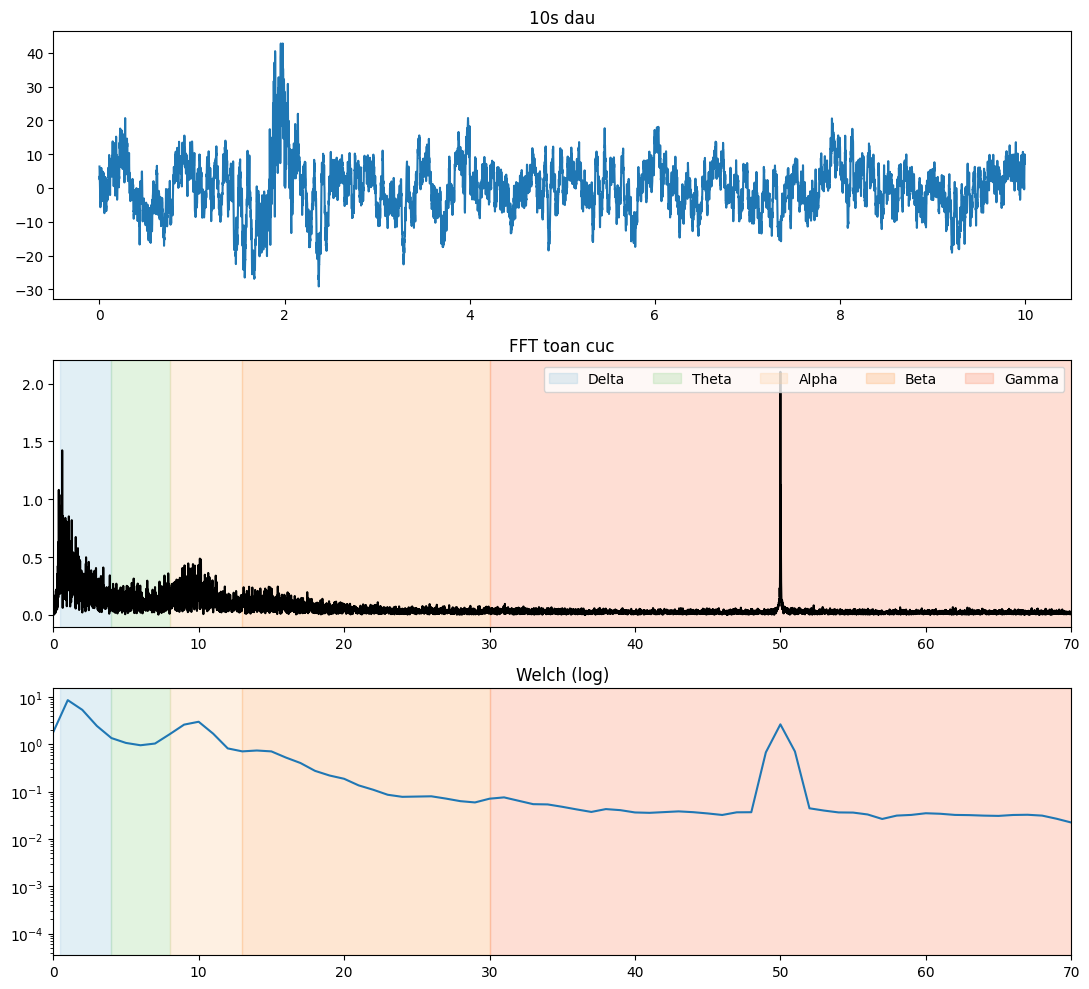

In [6]:
# CAU 6: Phan tich pho EEG
import numpy as np, matplotlib.pyplot as plt, scipy.fftpack as sfft
import scipy.signal, scipy.io as sio

m = sio.loadmat('EEGrestingState.mat')
eeg = m['eegdata'].flatten().astype(float)
fs = int(m['srate'][0,0])
N = len(eeg); t = np.arange(N)/fs

X = sfft.fft(eeg)/N
hz = np.linspace(0, fs/2, N//2+1)
ampl = 2*np.abs(X[:len(hz)]); ampl[0] /= 2

f_w, Pxx_w = scipy.signal.welch(eeg, fs, nperseg=fs, noverlap=fs//2)

bands = {'Delta':(0.5,4,'#9ecae1'), 'Theta':(4,8,'#a1d99b'),
         'Alpha':(8,13,'#fdd0a2'), 'Beta':(13,30,'#fdae6b'),
         'Gamma':(30,70,'#fc9272')}
total = np.sum(ampl**2)
for name,(lo,hi,_) in bands.items():
    mask = (hz>=lo)&(hz<hi)
    print(f'{name}: {100*np.sum(ampl[mask]**2)/total:.2f}%')

fig, axes = plt.subplots(3, 1, figsize=(11, 10))
axes[0].plot(t[:10*fs], eeg[:10*fs]); axes[0].set_title('10s dau')
for name,(lo,hi,c) in bands.items():
    axes[1].axvspan(lo, hi, alpha=0.3, color=c, label=name)
axes[1].plot(hz, ampl, 'k'); axes[1].set_xlim([0, 70]); axes[1].legend(ncol=5)
axes[1].set_title('FFT toan cuc')
for name,(lo,hi,c) in bands.items():
    axes[2].axvspan(lo, hi, alpha=0.3, color=c)
axes[2].semilogy(f_w, Pxx_w); axes[2].set_xlim([0, 70])
axes[2].set_title('Welch (log)')
plt.tight_layout(); plt.savefig('cau6_eeg.png', dpi=150); plt.show()


**Phân tích:**

Ket qua phan bo nang luong:
  Delta (0.5-4 Hz):  43.44%   ← cao nhat
  Theta (4-8 Hz):     8.13%
  Alpha (8-13 Hz):   17.98%   ← noi bat thu hai
  Beta (13-30 Hz):    8.28%
  Gamma (30-70 Hz):  10.73%

Nhan xet va dien giai sinh ly:
- Delta chiem uu the (43%) — trong EEG nghi mat nham, thanh phan tan rat thap (drift dien cuc, dao dong cham ~1-2 Hz cua mang neuron lon) thuong co bien do lon nhat. Day la dac trung pho bien cua single-channel raw EEG (chua loc HP).
- Alpha (~18%) la dinh sinh ly noi bat thu hai — dac trung cua trang thai thu gian, tinh tao, mat nham. Khi sinh vien mo mat hoac tap trung, dinh nay se giam.
- Beta (~8%) tuong ung voi hoat dong nhan thuc nen, Gamma (~11%) co the chua nhieu EMG (co mat/co tran).
Welch on dinh hon FFT don (it noise floor) vi trung binh nhieu cua so → giam phuong sai uoc luong.

Tra loi cau hoi phu: Vi sao dinh Alpha 10 Hz thuong ro o vung cham khi nham mat?
Vung cham (occipital cortex) chua vo thi giac so cap V1. Khi nham mat, dau vao thi giac giam manh, mang neuron V1 chuyen sang trang thai 'nghi' va phat ra dao dong dong bo tu phat o khoang 10 Hz (Alpha). Khi mo mat, V1 bi kich hoat → neuron phan tan → Alpha 'bien mat' (hien tuong alpha blocking, Berger 1924). Day la co so cua nhieu ung dung BCI dua tren EEG (cho phep dieu khien thiet bi bang trang thai nham/mo mat).


## Câu 7 (1.5đ) — Lọc ảnh trong miền tần số 2D

**Tóm tắt:** Tai anh Lenna.png, FFT 2D va shift DC ve tam. Thiet ke bo loc Gauss 2D voi 3 muc σ=[0.05, 0.10, 0.20]. Tao anh low-pass (nhan voi G) va high-pass (nhan voi 1-G), tinh RMSE giua anh goc va anh sau low-pass. Ve bang 3×3 hien thi bo loc, anh low-pass va anh high-pass.


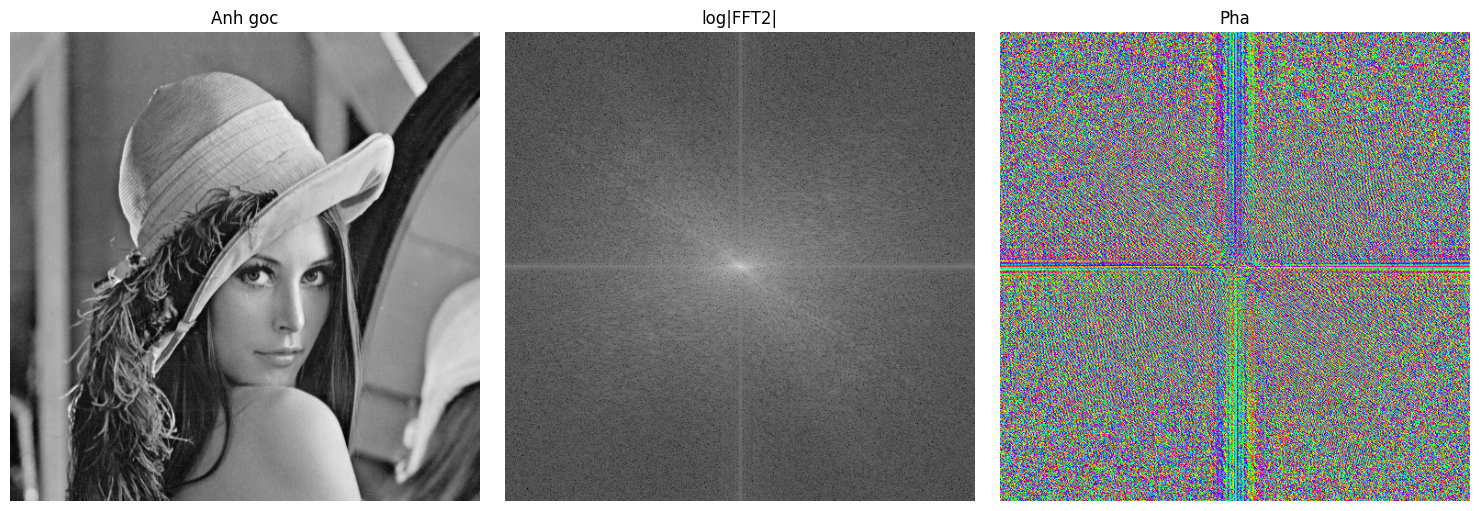

sigma=0.05: RMSE=22.50, giu 94.37% E
sigma=0.1: RMSE=16.39, giu 96.88% E
sigma=0.2: RMSE=11.38, giu 98.33% E


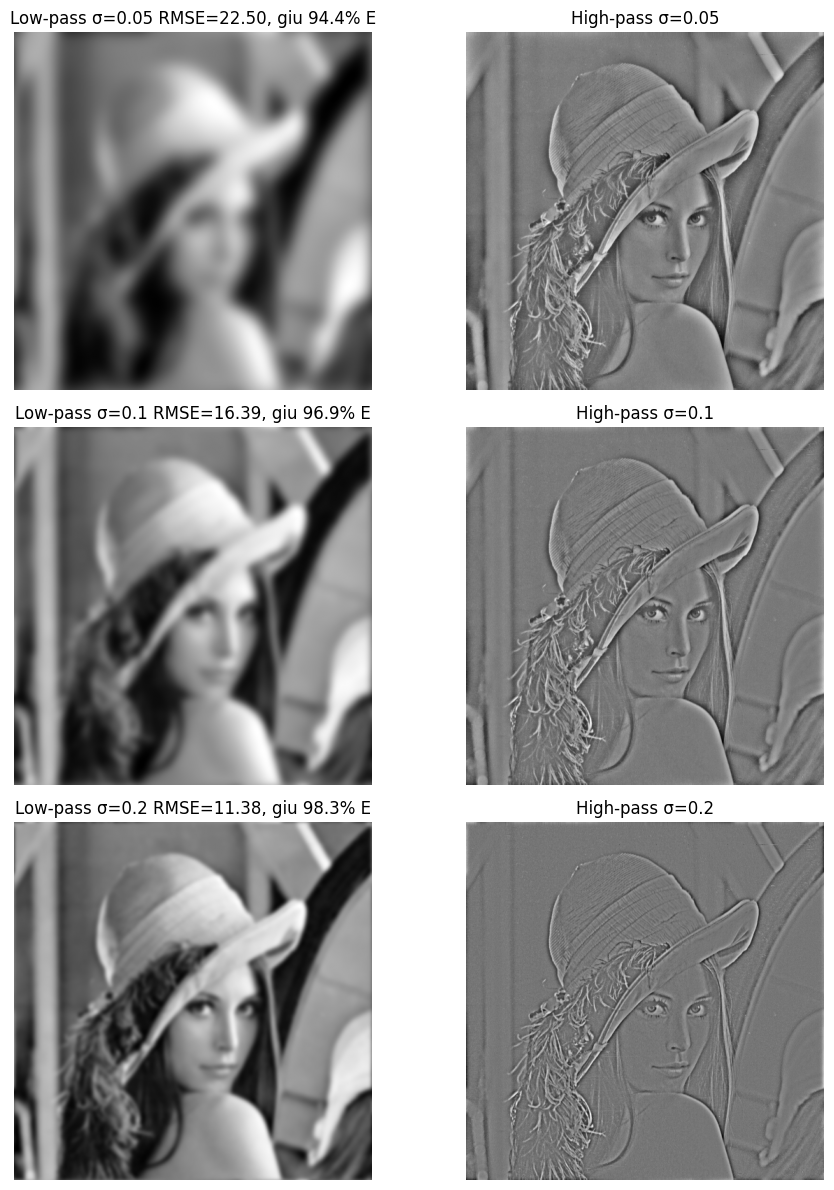

In [7]:
# CAU 7: Loc anh Gauss 2D
import numpy as np, matplotlib.pyplot as plt, scipy.fftpack as sfft
from scipy import stats
from PIL import Image

# Doc anh, chuyen grayscale = trung binh 3 kenh (theo de)
img_rgb = np.array(Image.open('Lenna.png').convert('RGB'), dtype=float)
img = img_rgb.mean(axis=2)

# FFT 2D va shift DC ve tam
F = sfft.fftshift(sfft.fft2(img))
log_mag = np.log(np.abs(F) + 1)
phase = np.angle(F)

# Hinh 1: anh goc, log|FFT2|, pha
fig1, ax1 = plt.subplots(1, 3, figsize=(15, 5))
ax1[0].imshow(img, cmap='gray'); ax1[0].set_title('Anh goc'); ax1[0].axis('off')
ax1[1].imshow(log_mag, cmap='gray'); ax1[1].set_title('log|FFT2|'); ax1[1].axis('off')
ax1[2].imshow(phase, cmap='hsv'); ax1[2].set_title('Pha'); ax1[2].axis('off')
plt.tight_layout(); plt.savefig('cau7_pho_anh.png', dpi=150); plt.show()

# Toa do chuan hoa (z-score) — DC o tam (0,0)
xr = stats.zscore(np.arange(img.shape[1]))
yr = stats.zscore(np.arange(img.shape[0]))
X, Y = np.meshgrid(xr, yr)

# Hinh 2: bang 3x2 — 3 sigma cho low/high-pass
sigmas = [0.05, 0.10, 0.20]
total_energy = np.sum(np.abs(F)**2)
fig, axes = plt.subplots(len(sigmas), 2, figsize=(10, 12))
for i, s in enumerate(sigmas):
    G = np.exp(-(X**2+Y**2)/(2*s**2))
    F_lp = F*G
    img_lp = np.real(sfft.ifft2(sfft.ifftshift(F_lp)))
    img_hp = np.real(sfft.ifft2(sfft.ifftshift(F*(1-G))))
    rmse = np.sqrt(np.mean((img-img_lp)**2))
    retain = np.sum(np.abs(F_lp)**2)/total_energy * 100
    print(f'sigma={s}: RMSE={rmse:.2f}, giu {retain:.2f}% E')
    axes[i,0].imshow(img_lp, cmap='gray')
    axes[i,0].set_title(f'Low-pass σ={s} RMSE={rmse:.2f}, giu {retain:.1f}% E')
    axes[i,1].imshow(img_hp, cmap='gray')
    axes[i,1].set_title(f'High-pass σ={s}')
    for a in axes[i]: a.axis('off')
plt.tight_layout(); plt.savefig('cau7_loc_anh.png', dpi=150); plt.show()


**Phân tích:**

Ket qua RMSE va % nang luong tan so giu lai sau low-pass:
  σ=0.05: RMSE=22.50, giu 94.37% E  (lam mo nhieu, mat chi tiet rieng nhung van giu phan lon nang luong tan thap)
  σ=0.10: RMSE=16.39, giu 96.88% E  (mo vua phai)
  σ=0.20: RMSE=11.38, giu 98.33% E  (mo nhe, giu duoc nhieu chi tiet)

Quan sat anh pho:
- log|FFT2| co diem sang manh o tam (DC) va lan giam dan ra ngoai (tan cao), kem theo vai tia sang doc/ngang ung voi cac canh sac nhe co dinh huong trong anh.
- Pha trong xu ly anh chua phan lon thong tin cau truc — neu hoan doi pha cua 2 anh khac nhau ta thay anh khoi phuc theo pha, KHONG theo bien do.

Bàn luận về mất thông tin:
- σ=0.05 chi mat 5.6% nang luong nhung RMSE lai cao (~22) — chung to nang luong tan cao tuy nho ve trong so nhung quan trong ve do nhan thuc (perceptual): chinh la canh, texture, chi tiet. Mat 5% E nay ma anh trong rat mo, doc/nhin kho.
- Tang σ tu 0.05→0.20: RMSE giam ~50% (22→11) trong khi % nang luong giu tang it (94→98%) → quan he phi tuyen giua nang luong tan so va chat luong cam nhan.
- High-pass (F·(1-G)) cho thay anh viền/canh; σ cang nho thi vien cang day cau truc, σ lon thi chi con bien gioi manh.

Tra loi cau hoi phu: HAI ung dung khac cua loc Gauss 2D (ngoai blur va sharpen):
1. Tien xu ly cho phat hien canh: thuat toan Canny dung Gauss 2D smooth truoc khi tinh gradient de giam nhieu — vi gradient rat nhay voi nhieu, khong smooth se sinh ra nhieu canh gia. Tuong tu, Laplacian-of-Gaussian (LoG) va Difference-of-Gaussian (DoG) la nen tang cua SIFT/SURF cho matching va dinh vi diem dac trung.
2. Xay dung kim tu thap Gauss (Gaussian pyramid) va Laplacian pyramid trong nen anh (image compression), tron anh (image blending), va multi-scale analysis. Apple/Google su dung pyramid blending cho panorama va portrait mode.
3. Bonus: noise reduction trong y khoa (MRI, CT) — Gauss isotropic 2D la xap xi optimal cho nhieu Gaussian voi gia thiet cau truc khong huong (di nhien voi cau truc co huong nguoi ta dung anisotropic diffusion).
